# DNA Hyperparameter Evolution Results

This notebook analyzes persisted artifacts from `experiments/evolution_convergence` to document outcomes for the DNA-style hyperparameter evolution work.

## What this notebook does

- Loads every run with `evolution_generation_summaries.json`
- Extracts per-generation fitness and gene statistics
- Compares final outcomes across runs
- Visualizes fitness trends, learning-rate dynamics, and boundary-collapse behavior
- Produces a compact interpretation summary for issue closure notes

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

EXPERIMENTS_ROOT = ROOT / "experiments" / "evolution_convergence"
assert EXPERIMENTS_ROOT.exists(), f"Missing directory: {EXPERIMENTS_ROOT}"

run_dirs = sorted(
    run_dir
    for run_dir in EXPERIMENTS_ROOT.iterdir()
    if run_dir.is_dir() and (run_dir / "evolution_generation_summaries.json").exists()
)

print(f"Project root: {ROOT}")
print(f"Experiments root: {EXPERIMENTS_ROOT}")
print(f"Discovered {len(run_dirs)} runs:")
for run_dir in run_dirs:
    print(f"  - {run_dir.name}")

Project root: /home/chris/AgentFarm
Experiments root: /home/chris/AgentFarm/experiments/evolution_convergence
Discovered 9 runs:
  - run_clamp_baseline_g6
  - run_clamp_penalty002_g6
  - run_clamp_penalty005_g6
  - run_clamp_penalty010_g6
  - run_clamp_penalty_g6
  - run_reflect_g6
  - run_roulette_mut040_g6
  - run_tournament_mut020_g6
  - run_tournament_mut025


In [2]:
generation_rows: list[dict[str, object]] = []
lineage_rows: list[dict[str, object]] = []
run_rows: list[dict[str, object]] = []

for run_dir in run_dirs:
    run_name = run_dir.name
    summary_path = run_dir / "evolution_generation_summaries.json"
    lineage_path = run_dir / "evolution_lineage.json"
    manifest_path = run_dir / "run_manifest.json"

    summaries = json.loads(summary_path.read_text())
    lineage = json.loads(lineage_path.read_text()) if lineage_path.exists() else []
    manifest = json.loads(manifest_path.read_text()) if manifest_path.exists() else {}

    if not summaries:
        continue

    for generation_entry in summaries:
        gene_stats = generation_entry.get("gene_statistics", {})
        generation_rows.append(
            {
                "run": run_name,
                "generation": generation_entry.get("generation"),
                "best_fitness": generation_entry.get("best_fitness"),
                "mean_fitness": generation_entry.get("mean_fitness"),
                "min_fitness": generation_entry.get("min_fitness"),
                "diversity": generation_entry.get("diversity"),
                "adaptive_event": generation_entry.get("adaptive_event"),
                "learning_rate_mean": gene_stats.get("learning_rate", {}).get("mean"),
                "learning_rate_std": gene_stats.get("learning_rate", {}).get("std"),
                "learning_rate_min": gene_stats.get("learning_rate", {}).get("min"),
                "learning_rate_max": gene_stats.get("learning_rate", {}).get("max"),
                "gamma_mean": gene_stats.get("gamma", {}).get("mean"),
                "epsilon_decay_mean": gene_stats.get("epsilon_decay", {}).get("mean"),
            }
        )

    for candidate in lineage:
        lineage_rows.append(
            {
                "run": run_name,
                "generation": candidate.get("generation"),
                "candidate_id": candidate.get("candidate_id"),
                "fitness": candidate.get("fitness"),
                "learning_rate": candidate.get("learning_rate"),
            }
        )

    final_entry = max(summaries, key=lambda entry: entry["generation"])
    final_gen = final_entry["generation"]
    final_gene_stats = final_entry.get("gene_statistics", {})

    final_lineage = [c for c in lineage if c.get("generation") == final_gen]
    lower_bound_hits = sum(np.isclose(c.get("learning_rate", np.nan), 1e-6) for c in final_lineage)
    final_population = len(final_lineage) if final_lineage else np.nan
    lower_bound_fraction = (lower_bound_hits / final_population) if final_population else np.nan

    run_rows.append(
        {
            "run": run_name,
            "selection_method": manifest.get("selection_method", "unknown"),
            "mutation_rate": manifest.get("mutation_rate", np.nan),
            "mutation_scale": manifest.get("mutation_scale", np.nan),
            "seed": manifest.get("seed", np.nan),
            "generations": manifest.get("generations", len(summaries)),
            "population_size": manifest.get("population_size", final_population),
            "final_generation": final_gen,
            "final_best_fitness": final_entry.get("best_fitness"),
            "final_mean_fitness": final_entry.get("mean_fitness"),
            "final_diversity": final_entry.get("diversity"),
            "final_lr_mean": final_gene_stats.get("learning_rate", {}).get("mean"),
            "final_lr_std": final_gene_stats.get("learning_rate", {}).get("std"),
            "final_lr_min": final_gene_stats.get("learning_rate", {}).get("min"),
            "final_lr_max": final_gene_stats.get("learning_rate", {}).get("max"),
            "final_gamma_mean": final_gene_stats.get("gamma", {}).get("mean"),
            "final_epsilon_decay_mean": final_gene_stats.get("epsilon_decay", {}).get("mean"),
            "final_lower_bound_hits": lower_bound_hits,
            "final_lower_bound_fraction": lower_bound_fraction,
        }
    )

df_gen = pd.DataFrame(generation_rows).sort_values(["run", "generation"]).reset_index(drop=True)
df_lineage = pd.DataFrame(lineage_rows).sort_values(["run", "generation", "candidate_id"]).reset_index(drop=True)
df_run = pd.DataFrame(run_rows).sort_values("final_best_fitness", ascending=False).reset_index(drop=True)

print(f"Generation rows: {len(df_gen)}")
print(f"Lineage rows: {len(df_lineage)}")
print(f"Run rows: {len(df_run)}")

display(df_run.head(10))

Generation rows: 56
Lineage rows: 464
Run rows: 9


,run,selection_method,mutation_rate,mutation_scale,seed,generations,population_size,final_generation,final_best_fitness,final_mean_fitness,final_diversity,final_lr_mean,final_lr_std,final_lr_min,final_lr_max,final_gamma_mean,final_epsilon_decay_mean,final_lower_bound_hits,final_lower_bound_fraction
0,run_reflect_g6,unknown,NaN,NaN,NaN,6,8,5,78.00,67.125000,0.082063,0.182302,0.042816,0.073403,0.228738,0.917637,0.838705,0,0.000
1,run_clamp_penalty002_g6,unknown,NaN,NaN,NaN,6,8,5,76.98,66.106801,0.065298,0.004504,0.011914,0.000001,0.036027,0.918995,0.731479,7,0.875
2,run_clamp_baseline_g6,unknown,NaN,NaN,NaN,6,8,5,76.00,66.625000,0.076578,0.009519,0.016517,0.000001,0.040119,0.953435,0.642043,6,0.750
3,run_roulette_mut040_g6,roulette,0.4,0.35,99.0,6,8,5,76.00,64.875000,0.207191,0.262892,0.246645,0.000001,0.705419,0.948644,0.792592,3,0.375
4,run_clamp_penalty010_g6,unknown,NaN,NaN,NaN,6,8,5,72.90,64.471506,0.050447,0.004504,0.011914,0.000001,0.036027,0.934460,0.569677,7,0.875
5,run_tournament_mut020_g6,tournament,0.2,0.20,42.0,6,8,5,71.00,64.375000,0.075138,0.004504,0.011914,0.000001,0.036027,0.926831,0.921433,7,0.875
6,run_tournament_mut025,unknown,NaN,NaN,NaN,8,10,7,71.00,64.800000,0.178053,0.348008,0.228922,0.000001,0.576099,0.813627,0.966945,1,0.100
7,run_clamp_penalty005_g6,unknown,NaN,NaN,NaN,6,8,5,68.95,62.695089,0.057464,0.004504,0.011914,0.000001,0.036027,0.875030,0.742176,7,0.875
8,run_clamp_penalty_g6,unknown,NaN,NaN,NaN,6,8,5,66.99,62.736250,0.111351,0.089727,0.098872,0.000001,0.236301,0.968995,0.670592,4,0.500


## Final-run leaderboard

This table highlights final-generation outcomes for each experiment directory.

In [3]:
leaderboard_cols = [
    "run",
    "selection_method",
    "mutation_rate",
    "mutation_scale",
    "final_best_fitness",
    "final_mean_fitness",
    "final_diversity",
    "final_lr_mean",
    "final_lr_std",
    "final_lower_bound_hits",
    "final_lower_bound_fraction",
]

display(
    df_run[leaderboard_cols]
    .sort_values("final_best_fitness", ascending=False)
    .style.format(
        {
            "mutation_rate": "{:.3f}",
            "mutation_scale": "{:.3f}",
            "final_best_fitness": "{:.3f}",
            "final_mean_fitness": "{:.3f}",
            "final_diversity": "{:.4f}",
            "final_lr_mean": "{:.6f}",
            "final_lr_std": "{:.6f}",
            "final_lower_bound_fraction": "{:.1%}",
        }
    )
)

,run,selection_method,mutation_rate,mutation_scale,final_best_fitness,final_mean_fitness,final_diversity,final_lr_mean,final_lr_std,final_lower_bound_hits,final_lower_bound_fraction
0,run_reflect_g6,unknown,nan,nan,78.000,67.125,0.0821,0.182302,0.042816,0,0.0%
1,run_clamp_penalty002_g6,unknown,nan,nan,76.980,66.107,0.0653,0.004504,0.011914,7,87.5%
2,run_clamp_baseline_g6,unknown,nan,nan,76.000,66.625,0.0766,0.009519,0.016517,6,75.0%
3,run_roulette_mut040_g6,roulette,0.400,0.350,76.000,64.875,0.2072,0.262892,0.246645,3,37.5%
4,run_clamp_penalty010_g6,unknown,nan,nan,72.900,64.472,0.0504,0.004504,0.011914,7,87.5%
5,run_tournament_mut020_g6,tournament,0.200,0.200,71.000,64.375,0.0751,0.004504,0.011914,7,87.5%
6,run_tournament_mut025,unknown,nan,nan,71.000,64.800,0.1781,0.348008,0.228922,1,10.0%
7,run_clamp_penalty005_g6,unknown,nan,nan,68.950,62.695,0.0575,0.004504,0.011914,7,87.5%
8,run_clamp_penalty_g6,unknown,nan,nan,66.990,62.736,0.1114,0.089727,0.098872,4,50.0%


## Fitness and learning-rate dynamics by generation

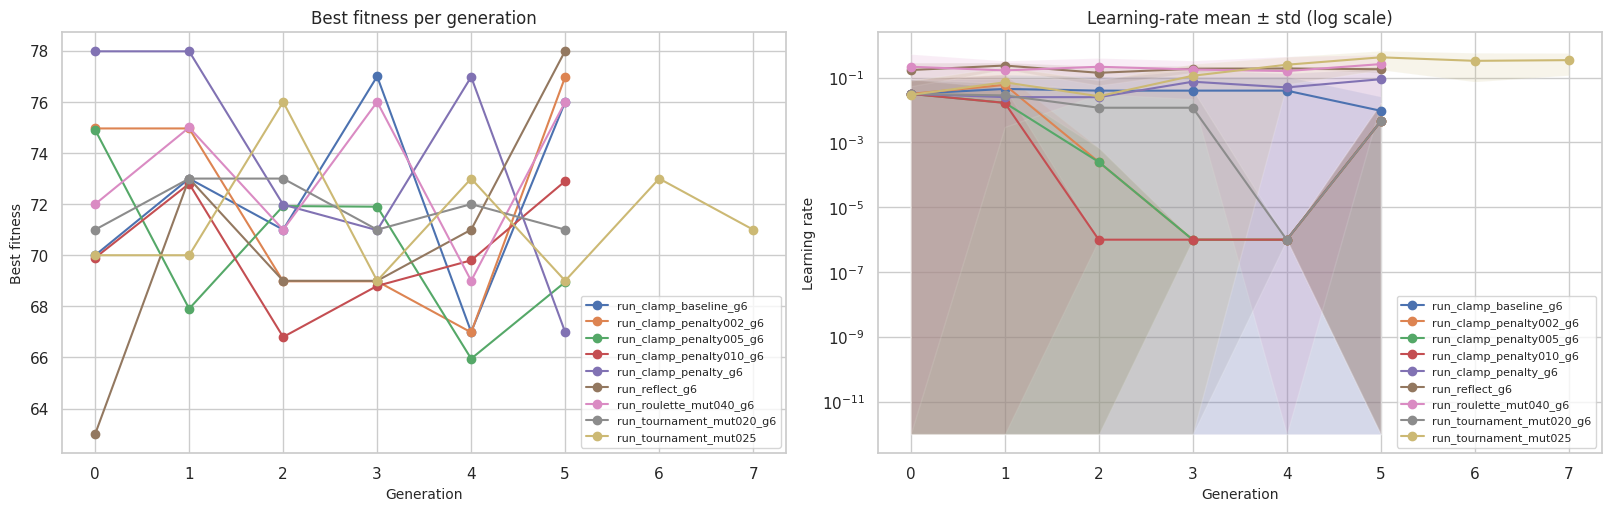

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

for run_name, group in df_gen.groupby("run"):
    axes[0].plot(group["generation"], group["best_fitness"], marker="o", label=run_name)

axes[0].set_title("Best fitness per generation")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Best fitness")
axes[0].legend(loc="best", fontsize=8)

for run_name, group in df_gen.groupby("run"):
    x = group["generation"].to_numpy()
    mean = group["learning_rate_mean"].to_numpy(dtype=float)
    std = group["learning_rate_std"].to_numpy(dtype=float)
    axes[1].plot(x, mean, marker="o", label=run_name)
    axes[1].fill_between(x, np.maximum(mean - std, 1e-12), mean + std, alpha=0.15)

axes[1].set_yscale("log")
axes[1].set_title("Learning-rate mean ± std (log scale)")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Learning rate")
axes[1].legend(loc="best", fontsize=8)

plt.show()

## Boundary-collapse diagnostics

This section measures how often candidate learning rates hit the configured lower bound (`1e-6`).

,run,generation,population,lower_bound_hits,best_fitness,lower_bound_fraction
0,run_clamp_baseline_g6,0,8,5,70.0000,0.625
1,run_clamp_baseline_g6,1,8,6,73.0000,0.750
2,run_clamp_baseline_g6,2,8,6,71.0000,0.750
3,run_clamp_baseline_g6,3,8,6,77.0000,0.750
4,run_clamp_baseline_g6,4,8,6,67.0000,0.750
5,run_clamp_baseline_g6,5,8,6,76.0000,0.750
6,run_clamp_penalty002_g6,0,8,5,74.9624,0.625
7,run_clamp_penalty002_g6,1,8,3,74.9624,0.375
8,run_clamp_penalty002_g6,2,8,6,68.9800,0.750
9,run_clamp_penalty002_g6,3,8,8,68.9800,1.000


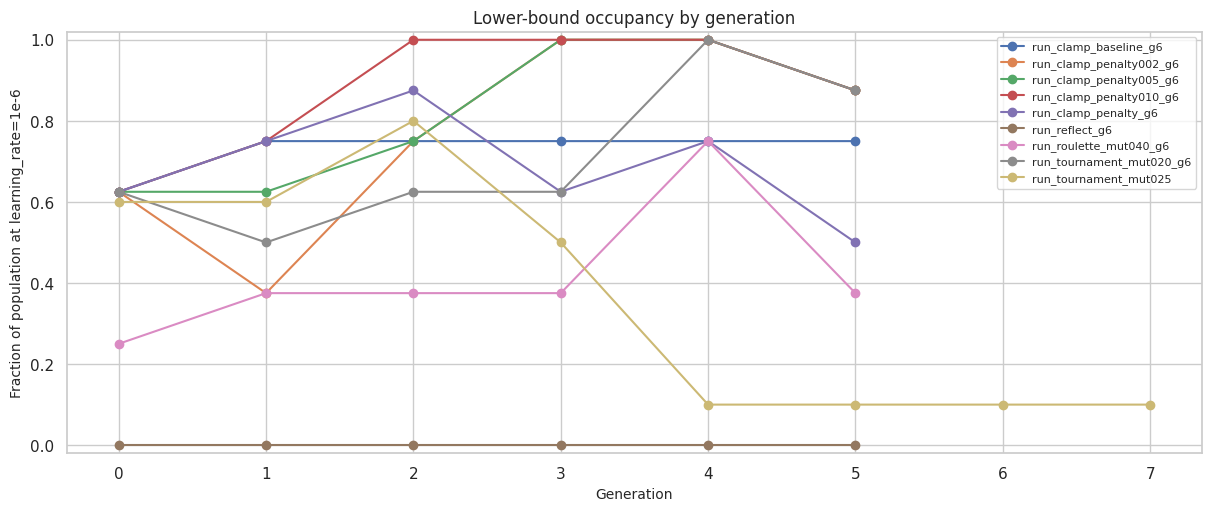

In [5]:
if df_lineage.empty:
    raise ValueError("Lineage data is empty; cannot compute boundary diagnostics.")

boundary = (
    df_lineage.assign(at_lower_bound=lambda d: np.isclose(d["learning_rate"], 1e-6))
    .groupby(["run", "generation"], as_index=False)
    .agg(
        population=("candidate_id", "count"),
        lower_bound_hits=("at_lower_bound", "sum"),
        best_fitness=("fitness", "max"),
    )
)
boundary["lower_bound_fraction"] = boundary["lower_bound_hits"] / boundary["population"]

display(boundary.head(12))

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
for run_name, group in boundary.groupby("run"):
    ax.plot(group["generation"], group["lower_bound_fraction"], marker="o", label=run_name)

ax.set_title("Lower-bound occupancy by generation")
ax.set_xlabel("Generation")
ax.set_ylabel("Fraction of population at learning_rate=1e-6")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="best", fontsize=8)
plt.show()

## Selection strategy comparison

## Auto-generated interpretation

The text below is generated from the loaded artifacts so it stays current when runs are regenerated.

In [6]:
# Optional: persist compact CSV exports for issue write-ups
exports_dir = ROOT / "experiments" / "evolution_convergence" / "_notebook_exports"
exports_dir.mkdir(parents=True, exist_ok=True)

df_run.to_csv(exports_dir / "run_summary.csv", index=False)
df_gen.to_csv(exports_dir / "generation_summary.csv", index=False)

print(f"Wrote CSV exports to: {exports_dir}")

Wrote CSV exports to: /home/chris/AgentFarm/experiments/evolution_convergence/_notebook_exports
